# 1. Imports

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# 2. Read the Parquet file

In [31]:
input_file = r"../data/processed/astorb_reduced.parquet"
astorb = pd.read_parquet(input_file)

Como o arquivo é relativamente pequeno para os padrões de ciência de dados, essa leitura direta para a memória é perfeitamente adequada.

# 3. Check for missing values

In [32]:
astorb.info()

<class 'pandas.DataFrame'>
RangeIndex: 1566820 entries, 0 to 1566819
Data columns (total 10 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   number  895910 non-null   Int64  
 1   name    1566820 non-null  str    
 2   H       1566820 non-null  float64
 3   G       1566820 non-null  float64
 4   a       1566820 non-null  float64
 5   e       1566820 non-null  float64
 6   inc     1566820 non-null  float64
 7   Omega   1566820 non-null  float64
 8   omega   1566820 non-null  float64
 9   M       1566820 non-null  float64
dtypes: Int64(1), float64(8), str(1)
memory usage: 135.0 MB


Isso mostra quantidade de registros, tipos das colunas e valores não nulos.

Para uma visão estatística das variáveis numéricas:

In [33]:
astorb.describe()

,number,H,G,a,e,inc,Omega,omega,M
count,895910.0,1.566820e+06,1.566820e+06,1.566820e+06,1.566820e+06,1.566820e+06,1.566820e+06,1.566820e+06,1.566820e+06
mean,447955.5,1.759826e+01,1.501344e-01,2.963193e+00,1.588113e-01,9.294357e+00,1.704496e+02,1.818317e+02,1.763537e+02
std,258627.084172,1.920720e+00,2.988291e-02,6.364757e+00,9.509876e-02,6.646425e+00,1.028792e+02,1.036870e+02,1.038033e+02
min,1.0,-1.260000e+00,0.000000e+00,4.617635e-01,3.748000e-05,6.032000e-03,2.230000e-04,6.210000e-04,3.750000e-04
25%,223978.25,1.672000e+01,1.500000e-01,2.400069e+00,9.265636e-02,4.361469e+00,8.287999e+01,9.200776e+01,8.650003e+01
50%,447955.5,1.760000e+01,1.500000e-01,2.668859e+00,1.473630e-01,7.870960e+00,1.619062e+02,1.837492e+02,1.727245e+02
75%,671932.75,1.847000e+01,1.500000e-01,3.029280e+00,2.043221e-01,1.267180e+01,2.564764e+02,2.714839e+02,2.660206e+02
max,895910.0,9.999000e+01,6.660000e+00,2.705611e+03,9.975172e-01,1.759751e+02,3.599999e+02,3.599998e+02,3.599997e+02


E, especificamente para os `NA`s:

In [34]:
na_counts = astorb.isna().sum()

na_counts[na_counts > 0]

number    670910
dtype: int64

# 4. Check the domain of the semimajor axis

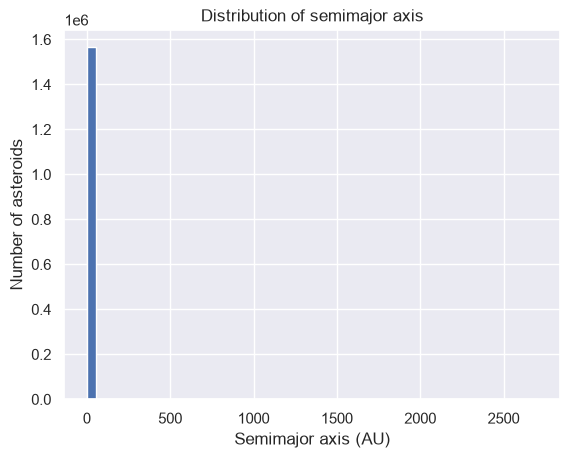

In [40]:
astorb["a"].plot.hist(bins=50)

plt.xlabel("Semimajor axis (AU)")
plt.ylabel("Number of asteroids")
plt.title("Distribution of semimajor axis")

plt.show()

# 5. Check for e >= 1.0

In [36]:
high_e = astorb[astorb["e"] >= 1.0]
high_e

,number,name,H,G,a,e,inc,Omega,omega,M


# 6. Cinturão principal

In [37]:
cinturao_principal = astorb[astorb["a"].between(2.1, 3.5)]

In [38]:
cinturao_principal.head()

,number,name,H,G,a,e,inc,Omega,omega,M
0,1,Ceres,3.34,0.15,2.765922,0.079751,10.587505,80.248993,73.208090,295.937548
1,2,Pallas,4.12,0.15,2.769387,0.230707,34.933695,172.887003,310.985633,275.616444
2,3,Juno,5.19,0.15,2.671013,0.255661,12.986942,169.810194,247.894048,285.308714
3,4,Vesta,3.25,0.15,2.361256,0.090227,7.143801,103.700084,151.440042,108.380989
4,5,Astraea,6.96,0.15,2.576761,0.187587,5.359799,141.448055,359.387522,205.288315


Text(0.5, 1.0, 'Distribution of semimajor axis')

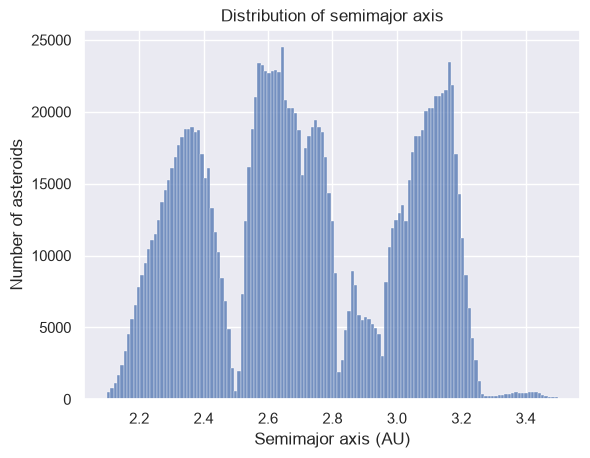

In [39]:
sns.set_theme()
sns.histplot(data = cinturao_principal, x='a')

plt.xlabel("Semimajor axis (AU)")
plt.ylabel("Number of asteroids")
plt.title("Distribution of semimajor axis")